# Lauching a simulation of vortex assembly and visualizing it 

In this notebook, we show how to reproduce the results presented in https://arxiv.org/abs/2504.13073. 
We choose the parameters of the simulation, and the interaction between the particles, and run it. 
This uses the C++ executable Sys. 

One might need to install json and subprocess packages.

## 1. Import the codes and define lattices
#### ▶️ Run Only

In [2]:
import json
import subprocess
import numpy as np
import os 

from LatticeTools import ReadLatticeParticle
from LatticeTools import DesignLEL
from LatticeTools import LELrepresentation

from System import ReadSeveralSystems
from System import ReadSystem

import matplotlib.pyplot as plt

from SideClasses import SideFunctions as SF
projectFolderName = os.getcwd()+"/" 
directoryLattice = projectFolderName+'Lattice/'   
directoryResults = projectFolderName+'Results/'   

Triangular = ReadLatticeParticle('Triangular', directoryLattice)  
Square = ReadLatticeParticle('Square', directoryLattice)  

## 2. Choose the system properties and the simulation parameters

#### 🔧 User Input
Here one can choose
- the name of the simulation `name`- this is the name of the folder that will be saved with the simulation results,
- the number of particles `Nparticles` in the system,
- the system size `L` (there is $L^2$ sites in the system),
- the number of Monte-Carlo steps per temperature `Nsteps_per_T`. The simulation performs a linear increase of the inverse temperature from $1/k_BT=0$ to $1/k_BT=1$ of $2000$ temperature increments,
- the number of simulations that will be ran sequentially `Nsystems`, which will allow to understand the variability from one annealing to the other,
- the type of vortex assembly `assembly_type`, defined in the supplement of the paper (Fig. S3 and S5). The possible assembly types are `"6-fold"`, `"3-fold"`,  `"4-fold"`,  `"fiber"`,  `"patterned-bulk"`, and  `"non-self-limited"`
- the energies of the crystalline and defect interactions $\epsilon_c$ and $\epsilon_d$: `epsilon_c` and `epsilon_d`. One can either define $\epsilon_c$ and $\epsilon_d$ individually, or define $\epsilon_c$ and the ratio $\epsilon_c/\epsilon_d$ which is the main control parameter, through the variable `energy_ratio`
- the forbidden energy, i.e. the energy of the other contacts `epsilon_f`

To reproduce the paper results, one can check table S1 of the supplements. The size and duration of simulations chosen for the paper results will typically last several hours. To visualize size-limitation, yet run simulations in a few minutes, we recommend to use `L=30`, `Nparticles=100` and `Nsteps_per_T=10**5`.

Careful, if you change the simulation parameters, make sure to also change the `name` of the simulation. Indeed, we do not erase previously saved parameter files. The code will run a simulation with the first parameter file saved for this simulation name.

In [4]:
name = "250929_vortex_assembly"
Nparticles = 100
L = 30
Nsteps_per_T = 10**5
Nsystems= 2


assembly_type = "6-fold"

epsilon_c = -18.7
energy_ratio = 0.407
epsilon_d = epsilon_c / energy_ratio 
epsilon_f = 50

## 3. Compute and visualize the interaction map 
#### ▶️ Run Only

This cell first loads the `designs` object from the `DesignLEL` class that allows to generate the interaction map, and the `visualisation` object from the `LELrepresentation` class to visualize it.
It then defines the interaction map, which is a vector, containing a list of energies corresponding to pairs of interactions. 
To show to which interactions each entry corresponds to, it visualizes the interaction map with the colors defined in Fig. S3 of the paper. 

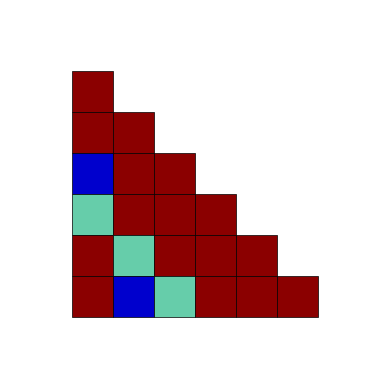

In [7]:
if assembly_type == "4-fold" or assembly_type == "non-self-limited":
    lattice = Square 
else:
    lattice = Triangular

designs = DesignLEL(lattice, 1)
visualisation = LELrepresentation(lattice, 1)

interaction_map = designs.interactions_vortex_assembly(epsilon_c, epsilon_d, epsilon_f, assembly_type=assembly_type)
color_map = designs.get_colormap_vortex_assembly( assembly_type=assembly_type)
visualisation.plot_matrix(designs.cut_LEL(interaction_map), fullMatrix=False, colordict=color_map)

## 4. Write in a folder the parameters file and define the functions to run the simulation
#### ▶️ Run Only

This cell defines the function launch_simu which uses subrpocess to run the executable Sys directly from the notebook. You might have to adapt this line if using a Windows machine for instance. You might need to modify the last line of this cell and replace it by the commented line. If this causes problem, it is also possible to run directly ./Sys (or Sys.exe) from the terminal, followed by the name of the directory where the parameter files have been stored. After that, one can directly go to section 6 of this notebook and visualize the results. 

In [9]:
folderResults = name
lattice_name = lattice.name
   
myParameters={}  
    
"""Geometry of the system """
myParameters["lattice"]= lattice.name
myParameters["Lx"]=L
myParameters["Ly"]=L 
myParameters["Lz"]= 1
myParameters["firstNeighborDistance"] = 1
myParameters["secondNeighborDistance"] = 2

"""Composition of the system"""
myParameters["NparticleTypes"]= 1 #int
myParameters["Nparticles"]=[Nparticles] # list of int of the size NparticleTypes

"""Montecarlo rate"""
myParameters["FlipRate"] = 0.5
myParameters["SwapRate"] = 0.5
myParameters["FlipSwapRate"] = 0
myParameters["MutationRate"] = 0
#the sum has to be one 

"""Annealing parameters"""
myParameters["Nsteps_per_T"]=Nsteps_per_T #int
myParameters["Ntemperatures"]=2000 #int
myParameters["Temperature_start"]= 5 #this number is not taken into account anymore 
myParameters["Temperature_end"]=1 
myParameters["Type_temperature_ramp"]= "beta_linear" 

"""Quenching parameters"""
myParameters["Nsteps_quenching"]= 0 #int
myParameters["Temperature_quenching"]= 1


"""Measurement parameters - equlibration info"""
myParameters["saveSnapshot"] = True #bool
myParameters["Nmes_per_T"] = 0 #number of snapshot along 
    # the annealing -> usually zero, unless you want to make videos
myParameters["saveTemperatures"] = False #bool
myParameters["saveEnergies"] = False #bool
# if True, will save successive values of energy during the annealing, quenching, and statistics
myParameters["saveMCsuccess"] = False


"""Measurement parameters - statistics about system composition"""
myParameters["doStatistics"] = True
myParameters["Temperature_statistics"]= 1
myParameters["Naverage"]=Nsteps_per_T #int

myParameters["saveCovariance"] = True 
myParameters["saveExtendedScaffold"] = True # only useful for renormalisation


"""Measurement parameters - statistics about clusters"""
myParameters["Ncluster_measurements"]= 1 #int
myParameters["MC_steps_between_measurements"]= 10*L*L

def save_parameters_file(directoryResults, ide=None):
    directoryResults_mkdir = directoryResults
    directoryResults = directoryResults+str(ide)
    
    try :
        """We check if the parameter file exists already"""
        jsonFile = open(directoryResults+"input_parameters.json", "r")
        print('Parameters file '+directoryResults+"input_parameters.json"+' already exists\nWe do nothing')
        saved = False
    except:
        try :
            """The folder exists"""
            jsonFile = open(directoryResults+"input_parameters.json", "w")
        except :
            """We need to create the folder"""
            print('We create folder '+directoryResults)
            subprocess.run(['mkdir', directoryResults_mkdir])
            jsonFile = open(directoryResults+"input_parameters.json", "w")
            
        jsonFile.write(jsonString)
        jsonFile.close()
        saved = True
    return(saved)


def save_LEL_file(directoryResults, LEL):
    file_LEL=open(directoryResults+myParameters["LELfileSuffix"],'w')       
    energy_string=''
    for e in LEL:
        energy_string+=str(e)+' '
    energy_string+="#END"
    file_LEL.write(energy_string+"\n")       

def launch_simu(directoryResults):
    try :
        open(directoryResults+"_LEL_chosen.txt", "r")
        already_done = True
    except :
        already_done = False
        
    if already_done :
        print(directoryResults, 'aldready ran')
    else :
        subprocess.run(["./Sys", directoryResults])   # Best for mac and linux 
        # subprocess.run(["Sys.exe", directoryResults] # Best for windows
   

## 5. Run the simulation
#### ▶️ Run Only
The function that uses subprocess to launch the C++ executable with the parameter file.
At each inverse temperature $\beta = 1/k_BT$, the code displays the energy of the whole system, and the time it took to run these Monte-Carlo steps.

In [11]:
for n in range (Nsystems):
    
    myParameters["directoryInputs"]=directoryLattice #string
    myParameters["directoryResults"]= directoryResults+name+"/" +str(n) #string
    myParameters["directoryResultsRead"]= directoryResults+name+"/" +str(n)
    myParameters["directoryInputsRead"]=directoryLattice #string
    myParameters["LELfileSuffix"] = '_LEL.txt' #string
    
    jsonString = json.dumps(myParameters)    
    saved = save_parameters_file(directoryResults+name+"/" ,n)
    save_LEL_file(directoryResults+name+"/" +str(n), interaction_map)
    launch_simu(directoryResults+name+"/" +str(n))
    


We create folder /Users/lkoehler/Documents/SelfAssembly2/VortexAssembly/Results/250929_vortex_assembly/0
Energies : 0 0 0 0 0 0 0 0 0 0 0 0 0 0 -18.7 50 50 50 50 -45.9459 50 -18.7 -45.9459 50 50 50 50 -18.7 50 50 50 50 50 50 50 
Maximal radius of clusters of particle 5


30*30*1 Triangular lattice is initialized: 0 seconds
/Users/lkoehler/Documents/SelfAssembly2/VortexAssembly/Results/250929_vortex_assembly/0 was created: 0 seconds


The density of particles is 0.111111 -> 100 particles
Energy per particle : 5.13


Beta=0.000000,Etot512.562155: 0 seconds
Beta=0.000500,Etot1004.016298: 0 seconds
Beta=0.001001,Etot1072.715818: 0 seconds
Beta=0.001501,Etot958.507742: 0 seconds
Beta=0.002001,Etot714.607447: 0 seconds
Beta=0.002501,Etot604.015661: 0 seconds
Beta=0.003002,Etot239.369574: 0 seconds
Beta=0.003502,Etot1093.861673: 0 seconds
Beta=0.004002,Etot999.961470: 0 seconds
Beta=0.004502,Etot564.606901: 0 seconds
Beta=0.005003,Etot987.360800: 0 seconds
Beta=0.005503,Etot738.930830: 0 seconds
Beta=0.006003,Etot425.159994: 0 seconds
Beta=0.006503,Etot330.822168: 0 seconds
Beta=0.007004,Etot781.260176: 0 seconds
Beta=0.007504,Etot470.230742: 0 seconds
Beta=0.008004,Etot416.614378: 0 seconds
Beta=0.008504,Etot515.738710: 0 seconds
Beta=0.009005,Etot222.714327: 0 seconds
Beta=0.009505,Etot439.368444: 0 seconds
Beta=0.010005,Etot322.714201: 0 seconds
Beta=0.010505,Etot652.006224: 0 seconds
Beta=0.011006,Etot36.884779: 0 seconds
Beta=0.011506,Etot101.968668: 0 seconds
Beta=0.012006,Etot24.722414: 0 seconds

Energy per particle : -65.36
Energy per particle : -65.36
4 clusters in this system
Energies : 0 0 0 0 0 0 0 0 0 0 0 0 0 0 -18.7 50 50 50 50 -45.9459 50 -18.7 -45.9459 50 50 50 50 -18.7 50 50 50 50 50 50 50 
Maximal radius of clusters of particle 5


saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
Statistics during 100000 MC steps at T=1.000000kT: 0 seconds
Cluster measurements (1 measures): 0 seconds
Simulation duration: 91 seconds
30*30*1 Triangular lattice is initialized: 0 seconds
/Users/lkoehler/Documents/SelfAssembly2/VortexAssembly/Results/250929_vortex_assembly/1 was created: 0 seconds


The density of particles is 0.111111 -> 100 particles
Energy per particle : 10.98


Beta=0.000000,Etot1097.516214: 0 seconds
Beta=0.000500,Etot903.577513: 0 seconds
Beta=0.001001,Etot891.415178: 0 seconds
Beta=0.001501,Etot716.615740: 0 seconds
Beta=0.002001,Etot568.661604: 0 seconds
Beta=0.002501,Etot1064.607603: 0 seconds
Beta=0.003002,Etot484.440111: 0 seconds
Beta=0.003502,Etot712.123571: 0 seconds
Beta=0.004002,Etot325.161314: 0 seconds
Beta=0.004502,Etot1152.007471: 0 seconds
Beta=0.005003,Etot474.286051: 0 seconds
Beta=0.005503,Etot487.361330: 0 seconds
Beta=0.006003,Etot887.799601: 0 seconds
Beta=0.006503,Etot30.786066: 0 seconds
Beta=0.007004,Etot599.524160: 0 seconds
Beta=0.007504,Etot383.708452: 0 seconds
Beta=0.008004,Etot360.078382: 0 seconds
Beta=0.008504,Etot-69.213186: 0 seconds
Beta=0.009005,Etot551.970606: 0 seconds
Beta=0.009505,Etot447.516745: 0 seconds
Beta=0.010005,Etot585.316671: 0 seconds
Beta=0.010505,Etot458.071047: 0 seconds
Beta=0.011006,Etot533.271097: 0 seconds
Beta=0.011506,Etot341.816816: 0 seconds
Beta=0.012006,Etot126.770712: 0 second

Energy per particle : -65.36
Energy per particle : -65.36
4 clusters in this system


saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
saveStat in MC_step_swap duration: 0 seconds
Statistics during 100000 MC steps at T=1.000000kT: 0 seconds
Cluster measurements (1 measures): 0 seconds
Simulation duration: 118 seconds


## 6. Visualize the simulation result
#### 🔧 User Input 
If several simulation were ran sequantially (in total, `Nsystems` simulation were performed), you can choose which simulation to show by changing `index_to_visualize` (it takes values between `0` and `Nsystems-1`).
This  cell loads the simulation results saved into the local directory `directoryResults`, into the object `R`. Then, it defines the colormap for the contacts, and displays the system state at the end of the annealing.

Load  /Users/lkoehler/Documents/SelfAssembly2/VortexAssembly/Results/250929_vortex_assembly
/Users/lkoehler/Documents/SelfAssembly2/VortexAssembly/Results/
2 Nsimu in this folder
1% loaded in 0.0 min


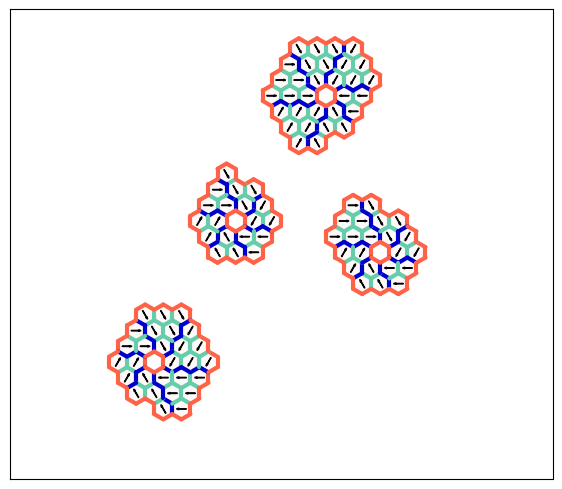

In [20]:
index_to_visulaize = 1
R = ReadSeveralSystems(name, directoryResults)
color_map = designs.get_colormap_vortex_assembly(assembly_type=assembly_type)
R.plot_state(index_to_visulaize, representation="arrowed", plot_contact=True, color_map_contacts = color_map)